Labsheet-6 Uday saini (cu24250246) B.Tech cse Sec-C Roll No :61

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from google.colab import files

Saving tigerr.jfif to tigerr.jfif
Image: tigerr.jfif
Image size: (360, 540, 3)


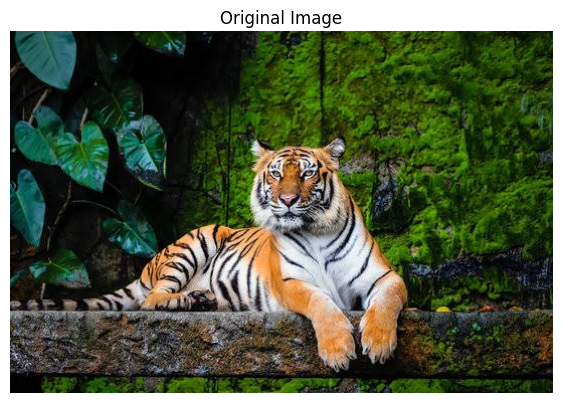

In [ ]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Image:", image_path)

# Read image
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image could not be loaded.")

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Image size:", image.shape)

plt.figure(figsize=(7, 5))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

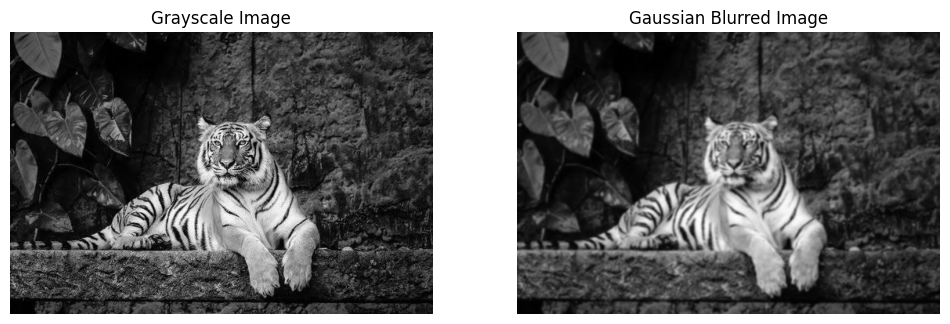

In [ ]:
# Apply Gaussian Blur
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap='gray')
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.show()

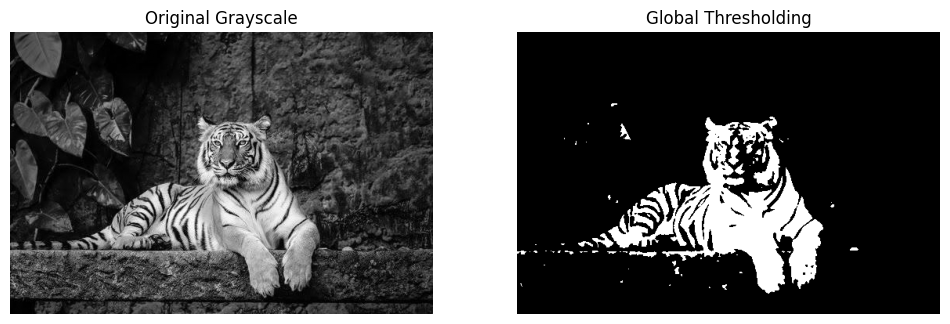

In [ ]:
# Choose global threshold
threshold_value = 127

_, global_threshold = cv2.threshold(
    blurred,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(global_threshold, cmap='gray')
plt.title("Global Thresholding")
plt.axis("off")

plt.show()

Automatically selected Otsu threshold: 103.0


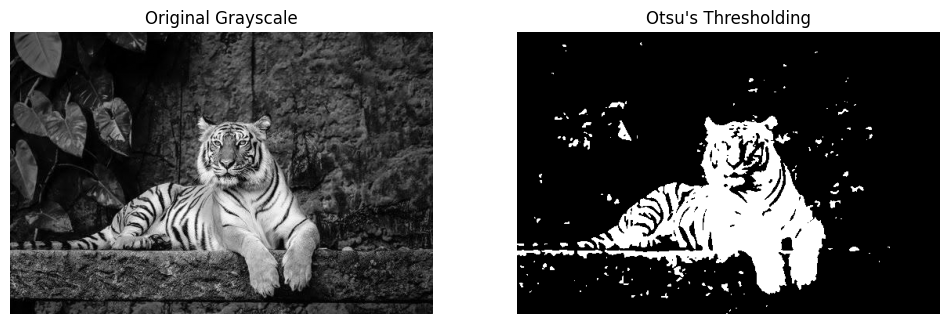

In [ ]:
# Otsu's Thresholding
otsu_threshold_value, otsu_threshold = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Automatically selected Otsu threshold:",
      otsu_threshold_value)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(otsu_threshold, cmap='gray')
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.show()

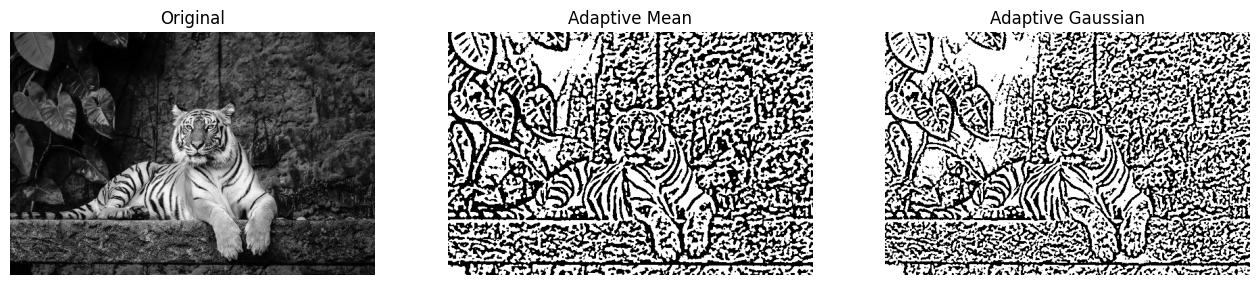

In [ ]:
# Adaptive Mean Thresholding
adaptive_mean = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# Adaptive Gaussian Thresholding
adaptive_gaussian = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(adaptive_mean, cmap='gray')
plt.title("Adaptive Mean")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(adaptive_gaussian, cmap='gray')
plt.title("Adaptive Gaussian")
plt.axis("off")

plt.show()

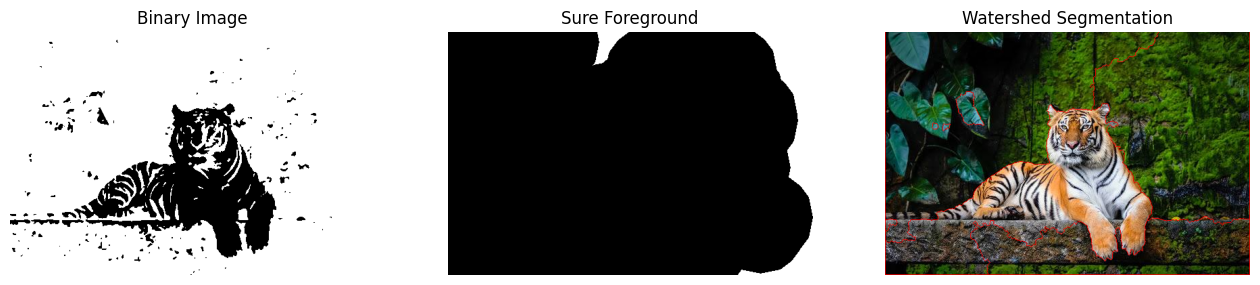

In [ ]:
# Convert image to binary using Otsu
_, binary = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Remove noise using morphological opening
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# Sure background
sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)

# Distance transform
dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# Sure foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

# Marker labelling
num_markers, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels
markers = markers + 1

# Mark unknown region as zero
markers[unknown == 255] = 0

# Apply Watershed
watershed_image = image_rgb.copy()

markers = cv2.watershed(
    image,
    markers
)

# Mark watershed boundaries
watershed_image[markers == -1] = [255, 0, 0]

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sure_fg, cmap='gray')
plt.title("Sure Foreground")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(watershed_image)
plt.title("Watershed Segmentation")
plt.axis("off")

plt.show()

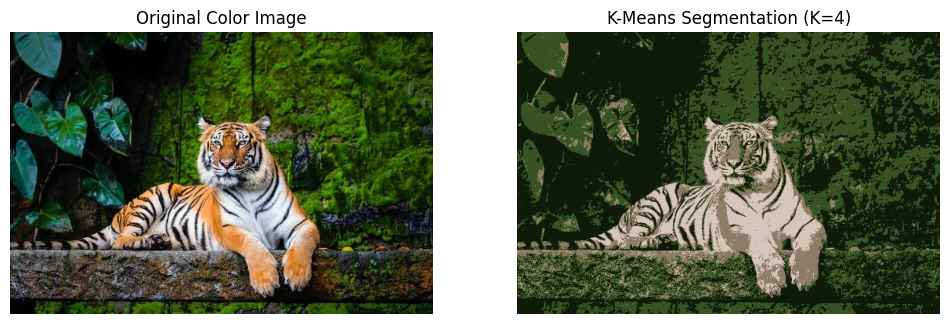

In [ ]:
# Convert image to RGB
img = image_rgb

# Reshape image into a list of pixels
pixel_data = img.reshape((-1, 3))

# Convert to float32
pixel_data = np.float32(pixel_data)

# Number of clusters
k = 4

# K-Means criteria
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)

# Apply K-Means
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixel_data)

# Cluster centers
centers = np.uint8(kmeans.cluster_centers_)

# Replace each pixel with its cluster center
segmented_pixels = centers[labels]

# Reshape back to image
segmented_image = segmented_pixels.reshape(img.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Color Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title(f"K-Means Segmentation (K={k})")
plt.axis("off")

plt.show()

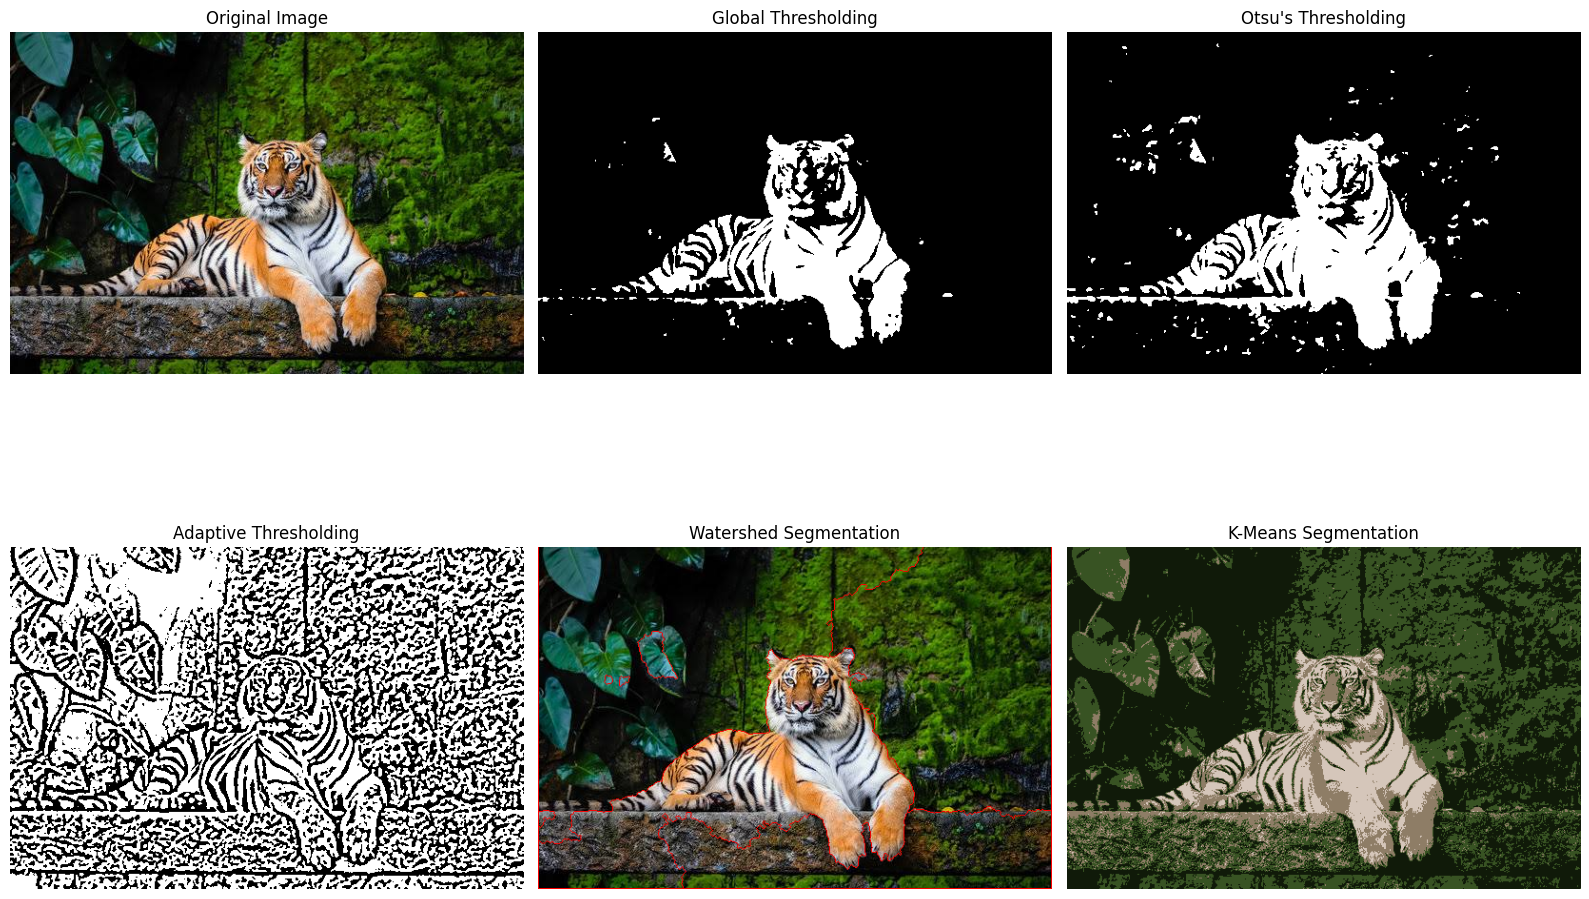